# Predição de churn

Notebook que documenta o passo a passo para entender e prever o cancelamento de clientes (churn) usando o dataset Telco Customer Churn ([link](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)).


## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Preparação dos dados

In [2]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
# tratando a coluna TotalCharges que estava com obj, mas é numerica
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

df['TotalCharges'].isnull().sum()

np.int64(11)

In [6]:
df.fillna({'TotalCharges':0}, inplace=True)

In [7]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [8]:
# transf a coluna Churn em 1 ou 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [9]:
# tirando essa coluna porque não irei precisar
df.drop('customerID', axis=1, inplace=True)

In [10]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## EDA

In [12]:
churn_counts = df['Churn'].value_counts(normalize=True) * 100

churn_counts

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

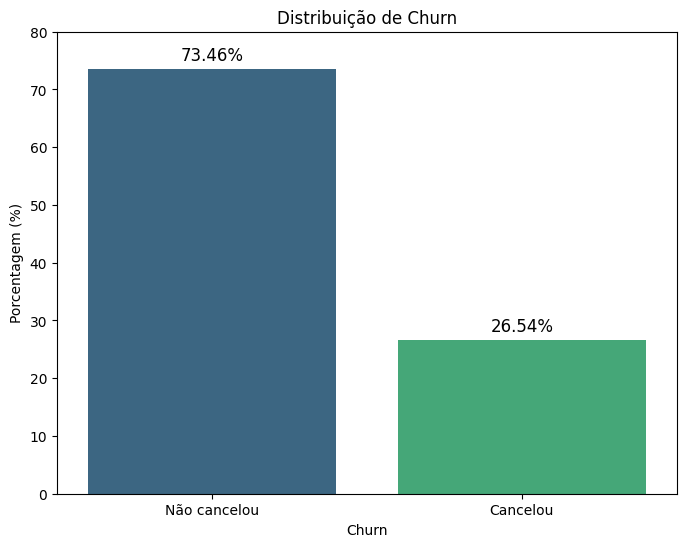

In [50]:
churn_counts = df['Churn'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 6))
ax = sns.barplot(x=churn_counts.index.map({0: 'Não cancelou', 1: 'Cancelou'}), y=churn_counts.values, hue=churn_counts.index.map({0: 'Não cancelou', 1: 'Cancelou'}), palette='viridis')
plt.title('Distribuição de Churn')
plt.xlabel('Churn')
plt.ylabel('Porcentagem (%)')
for p in ax.patches:
  ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
    ha='center', va='center', fontsize=12, color='black', xytext=(0, 10),
    textcoords='offset points')
plt.ylim(0, 80)
plt.show()

Apenas cerca de 26.5% dos clientes cancelaram. Isso indica que temos um desbalanceamento, mas ainda assim é possível construir um modelo útil.

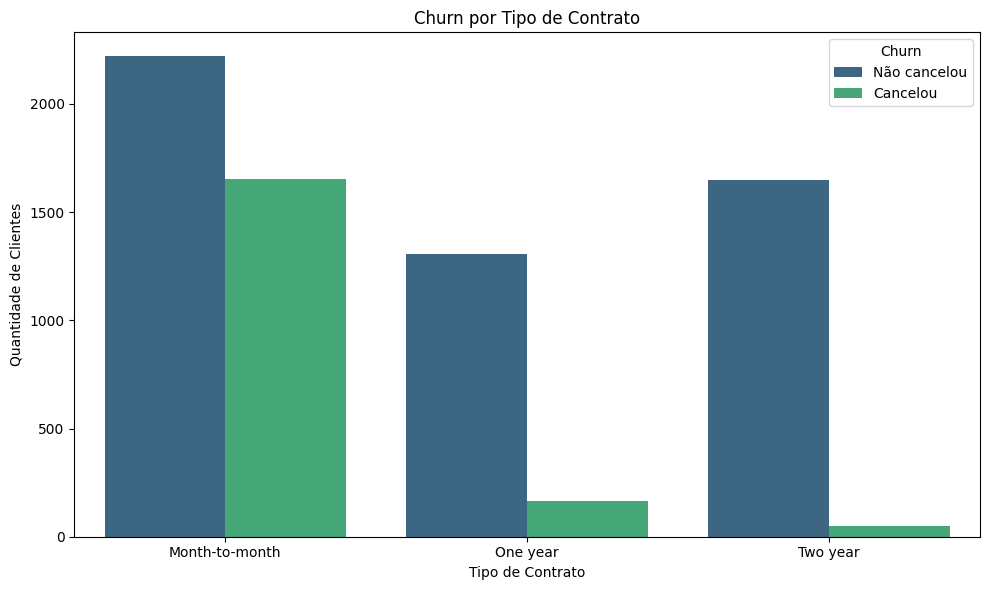

In [40]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Contract', hue='Churn', data=df, palette='viridis')
plt.title('Churn por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Quantidade de Clientes')
plt.legend(title='Churn', labels=['Não cancelou', 'Cancelou'])
plt.tight_layout()
plt.show()

Clientes com contrato mensal (Month-to-month) têm taxa de churn muito maior que os de contrato anual ou bienal. Isso sugere que a fidelização está fortemente associada ao tipo de contrato.

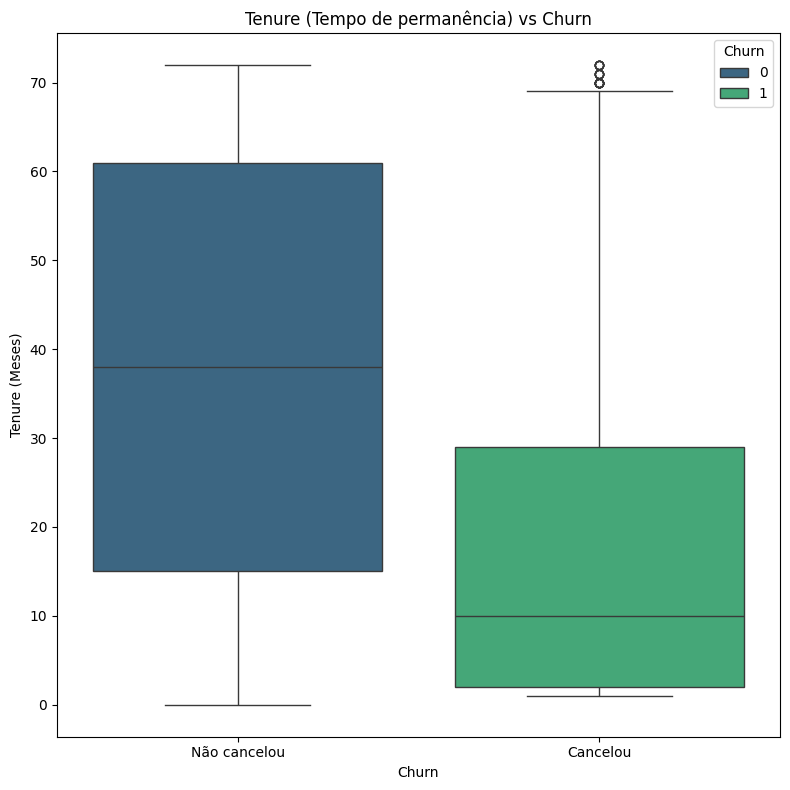

In [37]:
plt.figure(figsize=(8, 8))
sns.boxplot(x='Churn', y='tenure', data=df, palette='viridis', hue='Churn')
plt.title('Tenure (Tempo de permanência) vs Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (Meses)')
plt.xticks([0, 1], ['Não cancelou', 'Cancelou'])
plt.tight_layout()
plt.show()


A mediana de tenure para clientes que cancelam é bem menor (~10 meses) comparada aos que ficam (~38 meses). 
Clientes novos estão mais propensos a deixar o serviço.

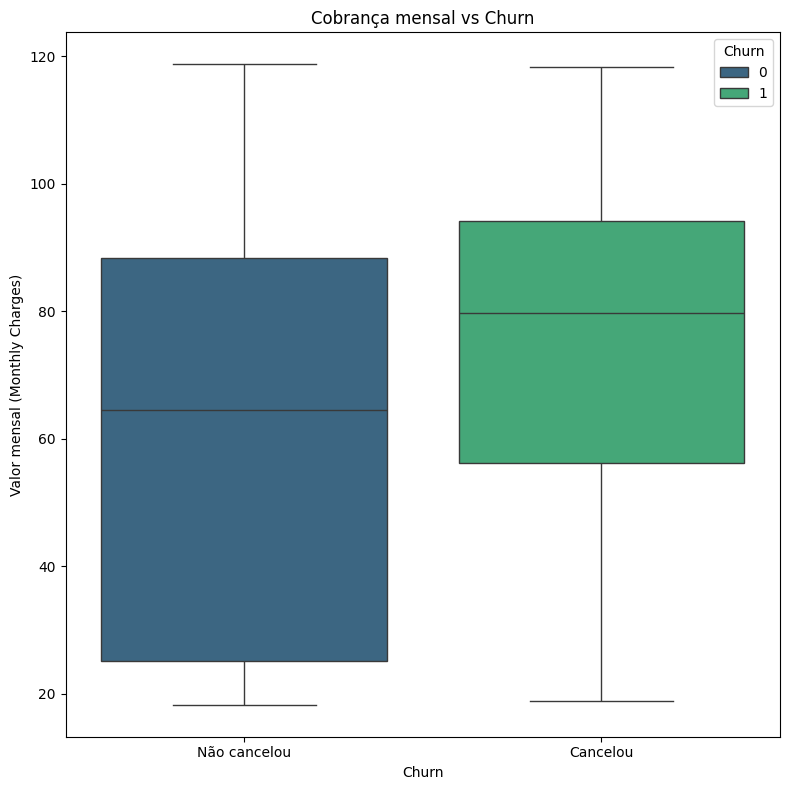

In [52]:
plt.figure(figsize=(8, 8))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='viridis', hue='Churn')
plt.title('Cobrança mensal vs Churn')
plt.xlabel('Churn')
plt.ylabel('Valor mensal (Monthly Charges)')
plt.xticks([0, 1], ['Não cancelou', 'Cancelou'])
plt.tight_layout()
plt.show()

A mediana do valor mensal é mais alta entre os que cancelam, indicando que preços mais elevados podem influenciar na decisão de cancelamento.